In [1]:
import cpandas as pd

In [2]:
veri = pd.read_csv("cars_tr.csv")
veri.head()

,ilanBasligi,adres,il,fiyat(TRY),ilanID,ilanTarihi,marka,seri,model,kilometre(Km),...,kasaTipi,renk,motorHacmi(Cc),motorGucu(HP),cekisTipi,boyaParcaDurumu,takasUygunluk,saticiTuru,aracVergisi(TRY),hasarGecmisi
0,2016 AUDİ A3 SPORTBACK 1.0 TFSI BOYASIZ/DEĞİŞE...,Aşağısoku Mh. Merkez,Bolu,1.169.000 TL,27812680,07 Nisan 2025,Audi,A3,A3 Sportback 1.0 TFSI Dynamic,2016.0,...,Hatchback/5,Beyaz,1200 cm3' e kadar,101 - 125 HP,Önden Çekiş,Orjinal Sağ Arka Çamurluk Arka Kaput Sol Ar...,Takasa Uygun,NaN,NaN,NaN
1,2018 AUDİ A6 2.0 TDI QUATTRO SUNROOF MATRİX VA...,Güneşevler Mh. Altındağ,Ankara,2.450.000 TL,28816234,07 Nisan 2025,Audi,A6,A6 Sedan 2.0 TDI Quattro,2018.0,...,Sedan,Siyah,1968 cc,190 hp,4WD (Sürekli),Orjinal Arka Kaput Sağ Arka Kapı Sağ Ön Kap...,Takasa Uygun Değil,Galeriden,NaN,tutarı belirtilmemiş
2,Sahibinden Audi A4 Sedan 1.8 TFSI 2011 Model,Burmalı Mh. Merkez,Afyonkarahisar,750.000 TL,28781662,08 Nisan 2025,Audi,A4,A4 Sedan 1.8 TFSI,2011.0,...,Sedan,Beyaz,1798 cc,160 hp,Önden Çekiş,Orjinal Tavan Sol Ön Kapı Motor Kaputu Ön ...,Takasa Uygun Değil,Sahibinden,2.013,75.000
3,2016 AUDI A3 AMBİENTE *CAM TAVAN LED XENON HIZ...,Ilıca Mh. Manavgat,Antalya,1.195.000 TL,28731117,03 Nisan 2025,Audi,A3,A3 Sportback 1.6 TDI Ambiente,2016.0,...,Hatchback/5,Siyah,1598 cc,110 hp,Önden Çekiş,Orjinal Sağ Arka Çamurluk Arka Kaput Sağ Ar...,Takasa Uygun,Galeriden,1.606,tutarı yok
4,Sahibinden Audi A3 Sportback 1.6 TDI S-Line 20...,Uğur Mumcu Mh. Yenimahalle,Ankara,822.000 TL,28393351,02 Nisan 2025,Audi,A3,A3 Sportback 1.6 TDI Attraction,2012.0,...,Hatchback/5,Beyaz,1598 cc,105 hp,Önden Çekiş,Orjinal Sağ Arka Çamurluk Arka Kaput Sol Ar...,NaN,NaN,NaN,tutarı belirtilmemiş


In [4]:
veri.isna().sum()

ilanBasligi            0
adres                  0
il                     0
fiyat(TRY)             0
ilanID                 0
ilanTarihi             0
marka                  0
seri                   0
model                  1
kilometre(Km)          1
yıl                    0
vitesTipi              1
yakitTuru              1
kasaTipi             119
renk                2455
motorHacmi(Cc)       191
motorGucu(HP)        198
cekisTipi            237
boyaParcaDurumu        0
takasUygunluk       3797
saticiTuru          3098
aracVergisi(TRY)    4714
hasarGecmisi        3584
dtype: int64

In [28]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6675 entries, 0 to 6674
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ilanBasligi       6675 non-null   object 
 1   adres             6675 non-null   object 
 2   il                6675 non-null   object 
 3   fiyat(TRY)        6675 non-null   object 
 4   ilanID            6675 non-null   int64  
 5   ilanTarihi        6675 non-null   object 
 6   marka             6675 non-null   object 
 7   seri              6675 non-null   object 
 8   model             6674 non-null   object 
 9   kilometre(Km)     6674 non-null   float64
 10  yıl               6675 non-null   object 
 11  vitesTipi         6674 non-null   object 
 12  yakitTuru         6674 non-null   object 
 13  kasaTipi          6556 non-null   object 
 14  renk              4220 non-null   object 
 15  motorHacmi(Cc)    6484 non-null   object 
 16  motorGucu(HP)     6477 non-null   object 


In [417]:
cols = ["yil","fiyat(TRY)", "motorHacmi(Cc)", "motorGucu(HP)","hasarGecmisi"]
veri[cols] = veri[cols].astype(int)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [171]:
veri = veri.rename(columns={"kilometre(Km)": "yil"})
veri = veri.rename(columns={"yıl": "KM"})

In [175]:
veri["yil"].corr(veri["fiyat(TRY)"])

np.float64(0.3942546335627234)

In [343]:
cols = ["KM", "motorHacmi(Cc)", "motorGucu(HP)", "hasarGecmisi", "fiyat(TRY)"]

veri_temiz = veri.copy()

for col in cols:
    Q1 = veri_temiz[col].quantile(0.25)
    Q3 = veri_temiz[col].quantile(0.75)
    IQR = Q3 - Q1
    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR
    
    veri_temiz = veri_temiz[(veri_temiz[col] >= alt_sinir) & (veri_temiz[col] <= ust_sinir)]


In [345]:
veri_temiz["hasarGecmisi"] = veri_temiz["hasarGecmisi"].fillna(0)

In [347]:
veri_temiz["cekisTipi"].value_counts()

cekisTipi
Önden Çekiş      1119
Arkadan İtiş       10
4WD (Sürekli)       2
Name: count, dtype: int64

In [349]:
veri_temiz["cekisTipi"] = veri_temiz["cekisTipi"].fillna("Önden Çekiş")

In [351]:
veri_temiz["motorGucu(HP)"].value_counts().head(5)

motorGucu(HP)
90.0     136
110.0    113
75.0     103
115.0     84
105.0     70
Name: count, dtype: int64

In [249]:
veri_temiz["motorGucu(HP)"] = veri_temiz["motorGucu(HP)"].fillna(100)

In [353]:
veri_temiz["motorHacmi(Cc)"].value_counts().head(5)

motorHacmi(Cc)
1598.0    217
1461.0    154
1560.0     88
1390.0     75
1248.0     74
Name: count, dtype: int64

In [355]:
veri_temiz["motorHacmi(Cc)"] = veri_temiz["motorHacmi(Cc)"].fillna(1400)

In [357]:
veri_temiz["renk"].value_counts()

renk
Beyaz              373
Gri (Gümüş)        252
Siyah              243
Gri                 96
Mavi                37
Füme                36
Kırmızı             20
Gri (metalik)       16
Lacivert            14
Kahverengi          12
Mavi (metalik)      10
Gri (titanyum)       7
Bordo                6
Yeşil                4
Bej                  4
Şampanya             2
Yeşil (metalik)      2
Mor                  2
Sarı                 1
Diğer                1
Name: count, dtype: int64

In [359]:
import numpy as np

# Örnek renk listesi
renkler = ["Beyaz", "Gri", "Gri (Gümüş)", "Siyah"]

# NaN olan hücrelerin maskesi
mask = veri_temiz["renk"].isna()

# Rastgele renkleri seçip NaN olan hücrelere ata
veri_temiz.loc[mask, "renk"] = np.random.choice(renkler, size=mask.sum())

In [361]:
veri_temiz["kasaTipi"].value_counts()

kasaTipi
Hatchback/5      556
Sedan            489
Hatchback/3       35
MPV               30
Station wagon     26
Coupe              2
Name: count, dtype: int64

In [ ]:
# Örnek renk listesi
kasalar = ["Hatchback/5","Sedan"]

# NaN olan hücrelerin maskesi
mask = veri_temiz["kasaTipi"].isna()

# Rastgele renkleri seçip NaN olan hücrelere ata
veri_temiz.loc[mask,"kasaTipi"] = np.random.choice(kasalar, size=mask.sum())

In [365]:
veri_temiz.isna().sum()

ilanBasligi           0
adres                 0
il                    0
fiyat(TRY)            0
ilanID                0
ilanTarihi            0
marka                 0
seri                  0
model                 0
yil                   0
KM                    0
vitesTipi             0
yakitTuru             0
kasaTipi              0
renk                  0
motorHacmi(Cc)        0
motorGucu(HP)         0
cekisTipi             0
boyaParcaDurumu       0
takasUygunluk       728
saticiTuru          422
aracVergisi(TRY)    791
hasarGecmisi          0
dtype: int64

In [367]:
X = veri_temiz.drop(["ilanBasligi","adres","il","fiyat(TRY)","ilanID","ilanTarihi","takasUygunluk","saticiTuru","aracVergisi(TRY)"], axis=1)
y = veri_temiz["fiyat(TRY)"]

In [377]:
X.head()

,marka,seri,model,yil,KM,vitesTipi,yakitTuru,kasaTipi,renk,motorHacmi(Cc),motorGucu(HP),cekisTipi,boyaParcaDurumu,hasarGecmisi
6,Audi,A3,A3 Sedan 1.6 TDI Ambiente,2014.0,218000,Yarı Otomatik,Dizel,Sedan,Siyah,1598.0,110.0,Önden Çekiş,Orjinal - Lokal boyalı - Boyalı - Değişm...,3295.0
16,Audi,A3,A3 Sportback 1.4 TFSI Ambition,2009.0,214000,Yarı Otomatik,Benzin,Hatchback/5,Füme,1390.0,125.0,Önden Çekiş,Orjinal - Lokal boyalı Sol Ön Çamurluk Boy...,21000.0
41,Audi,A3,A3 Sportback 1.4 TFSI Ambiente,2010.0,235000,Yarı Otomatik,Benzin,Hatchback/5,Beyaz,1390.0,125.0,Önden Çekiş,Orjinal - Lokal boyalı Sağ Arka Çamurluk A...,30000.0
42,Audi,A3,A3 Sportback 1.6 TDI Attraction,2013.0,200000,Yarı Otomatik,Dizel,Hatchback/5,Beyaz,1598.0,105.0,Önden Çekiş,Orjinal - Lokal boyalı Sağ Arka Çamurluk B...,3000.0
44,Audi,A3,A3 Sportback 1.6 Attraction,2006.0,256060,Otomatik,LPG & Benzin,Hatchback/5,Gri (titanyum),1595.0,102.0,Önden Çekiş,Orjinal Tavan Ön Tampon Lokal boyalı - Bo...,8000.0


In [387]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cols =["marka", "seri", "model","vitesTipi", "yakitTuru", "kasaTipi", "renk", "cekisTipi", "boyaParcaDurumu"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot", one_hot, cols)],
                               remainder="passthrough")
transformed_X = transformer.fit_transform(X)

In [389]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [391]:
model.score(X_test, y_test)

0.8263880693103307

In [393]:
y_preds = model.predict(X_test)

In [399]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mean_absolute_error(y_true= y_test, y_pred= y_preds)

56550.30535087719

In [401]:
mean_squared_error(y_true= y_test, y_pred= y_preds)

5374652059.3717375

ValueError: Could not interpret value `fiyat` for `y`. An entry with this name does not appear in `data`.

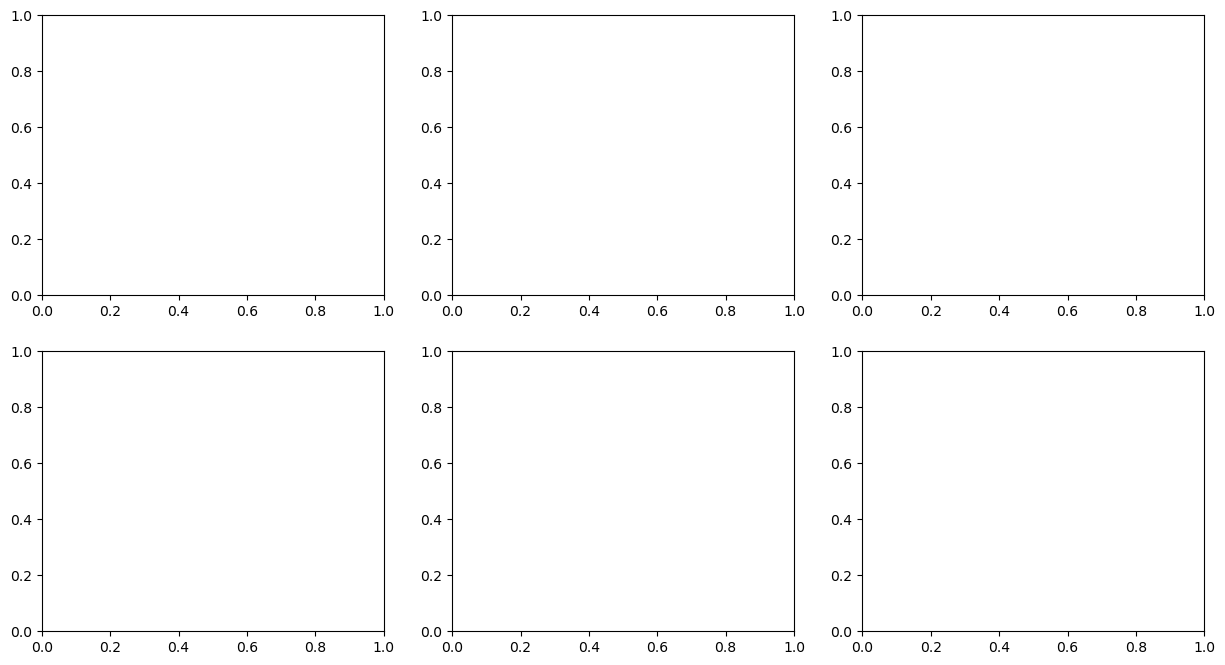

In [411]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sadece sayısal kolonları alıyoruz (target hariç)
numeric_cols = veri_temiz.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols.remove("fiyat(TRY)")  # hedef kolon

# Kaç plot olacak
n_cols = 3  # satır başına 3 plot
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # toplam satır sayısı

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(data=veri_temiz, x=col, y="fiyat", ax=axes[i])
    axes[i].set_title(f"{col} vs fiyat")

# Kalan boş subplotları sil
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
